<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../../utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Triple-Barrier Labeling &amp; Meta-Labeling
    </h1>
  </div>
</div>

Fixed-horizon labels ("up or down after N days?") ignore *how* the path got there
and the risk taken along the way. De Prado's **triple-barrier method** labels each
event by which of three barriers it hits first: an upper (profit-take), a lower
(stop-loss), or a vertical (time) barrier. The barrier widths scale with
**volatility**, and events are sampled with a **CUSUM filter** so we only label
when something meaningful has moved.

We run the full pipeline on the S&P 500 from FRED:

CUSUM event sampling → volatility-scaled barriers → triple-barrier labels →
meta-labels → trend-scanning labels.

Reference: López de Prado, *Advances in Financial Machine Learning*, Ch. 3.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")  # dark figures (RiskLabAI house style)
from fredapi import Fred

from RiskLabAI.data.labeling import (
    symmetric_cusum_filter,
    daily_volatility_with_log_returns,
    vertical_barrier,
    meta_events,
    meta_labeling,
    find_trend_using_trend_scanning,
)

## 1. Price series (FRED)

FRED returns `NaN` on market holidays, so we drop them before anything else.

In [2]:
close = Fred().get_series("SP500").dropna().astype(float)
print(f"{len(close)} observations, {close.index[0].date()} to {close.index[-1].date()}")

2514 observations, 2016-06-20 to 2026-06-18


## 2. Sample events with a CUSUM filter

The symmetric CUSUM filter fires when the cumulative up- or down-move exceeds a
threshold — flagging meaningful directional runs while ignoring noise. We size the
threshold from the data (a multiple of the average daily move).

In [3]:
threshold = 3.0 * close.diff().abs().mean()
events = symmetric_cusum_filter(close, threshold)
print(f"threshold = {threshold:.2f} → {len(events)} events")

threshold = 87.33 → 398 events


## 3. Volatility-scaled barriers

Barrier widths are set by a rolling estimate of daily volatility (so each label
reflects the same *risk-adjusted* move), and a 5-day **vertical** barrier caps the
holding period.

In [4]:
vol = daily_volatility_with_log_returns(close, span=50)
events = events[vol.reindex(events).notna()]          # keep events with a volatility estimate

vb = vertical_barrier(close, events, number_days=5)
print(f"usable events: {len(events)}   |   with a 5-day vertical barrier: {len(vb)}")

usable events: 398   |   with a 5-day vertical barrier: 396


## 4. Triple-barrier labels + meta-labeling

`meta_events` finds, for each event, which barrier is touched first (profit-take,
stop-loss, or time). `meta_labeling` turns the touched events into a label
(`+1` / `-1`) and the realized return — the targets a primary model learns, and
the foundation for a meta-model that decides *whether to act*.

labeled events: 397   |   +1: 230   -1: 167   |   mean return: 0.0013


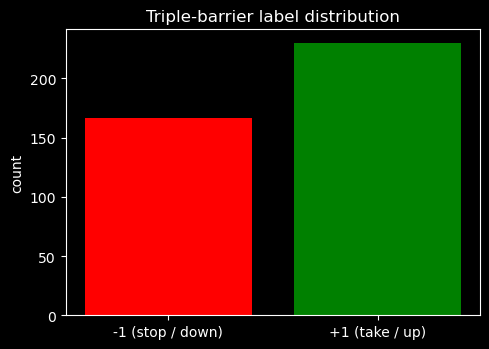

In [5]:
ev = meta_events(
    close=close, time_events=events, ptsl=[1.0, 1.0], target=vol,
    return_min=0.0, num_threads=1, vertical_barrier_times=vb, side=None,
)
ml = meta_labeling(ev, close)

n_up   = int((ml["Label"] == 1.0).sum())
n_down = int((ml["Label"] == -1.0).sum())
print(f"labeled events: {len(ml)}   |   +1: {n_up}   -1: {n_down}   |   "
      f"mean return: {ml['Return'].mean():.4f}")

plt.figure(figsize=(5, 3.6))
plt.bar(["-1 (stop / down)", "+1 (take / up)"], [n_down, n_up], color=["red", "green"])
plt.ylabel("count"); plt.title("Triple-barrier label distribution")
plt.tight_layout(); plt.show()

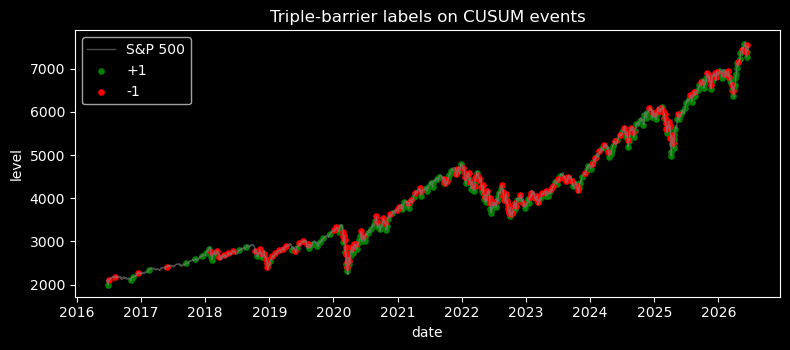

In [6]:
up_events   = ml.index[ml["Label"] == 1.0]
down_events = ml.index[ml["Label"] == -1.0]

plt.figure(figsize=(8, 3.6))
plt.plot(close.index, close.values, lw=1, c="gray", alpha=0.6, label="S&P 500")
plt.scatter(up_events,   close.reindex(up_events),   c="green", s=14, label="+1")
plt.scatter(down_events, close.reindex(down_events), c="red",   s=14, label="-1")
plt.xlabel("date"); plt.ylabel("level")
plt.title("Triple-barrier labels on CUSUM events")
plt.legend(loc="upper left"); plt.tight_layout(); plt.show()

## 5. Bonus: trend-scanning labels

An alternative to the triple barrier: **trend scanning** labels each event by the
sign and strength (t-value) of the best-fitting local trend over horizons in a
given range — no barriers or volatility targets required.

In [7]:
trend = find_trend_using_trend_scanning(molecule=events, close=close, span=(5, 21))
counts = trend["Trend"].value_counts().to_dict()
print(f"trend-scanning labels — up: {counts.get(1.0, 0)}, "
      f"down: {counts.get(-1.0, 0)}, flat: {counts.get(0.0, 0)}")
trend.head()

trend-scanning labels — up: 255, down: 136, flat: 0


,End Time,t-Value,Trend
2016-06-27,2016-07-26,10.19564,1.0
2016-06-30,2016-07-29,9.66868,1.0
2016-08-05,2016-09-02,-2.915518,-1.0
2016-11-02,2016-12-01,10.557245,1.0
2016-11-15,2016-12-14,7.083366,1.0


## Takeaways

- **CUSUM** sampling labels only meaningful moves, avoiding the redundancy of
  fixed-interval sampling.
- The **triple-barrier** method produces path-aware, risk-adjusted labels (which
  of profit-take / stop-loss / time is hit first).
- **Meta-labeling** sits on top: a primary model picks the side, a meta-model
  decides whether to take the bet — improving precision.
- **Trend scanning** is a barrier-free alternative based on local trend strength.

All from `RiskLabAI.data.labeling`: `symmetric_cusum_filter`,
`daily_volatility_with_log_returns`, `vertical_barrier`, `meta_events`,
`meta_labeling`, `find_trend_using_trend_scanning`.